Target Energi Max : 150 MeV
Rentang SOBP      : 13.39 cm hingga 15.64 cm


C:\Users\Asus\AppData\Local\Temp\ipykernel_31152\251004330.py:40: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  integral,_ = integrate.quad(func,d0,d1)/(d1-d0)


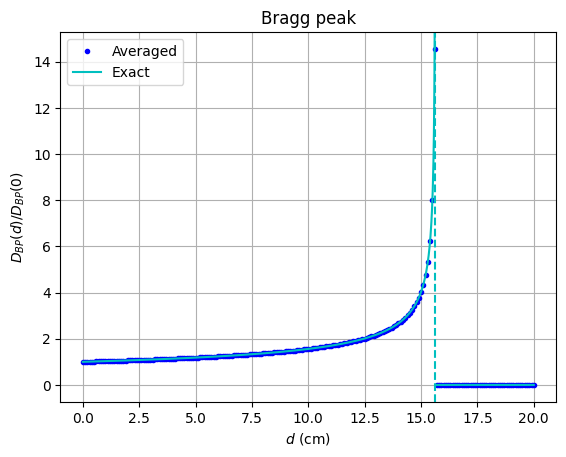

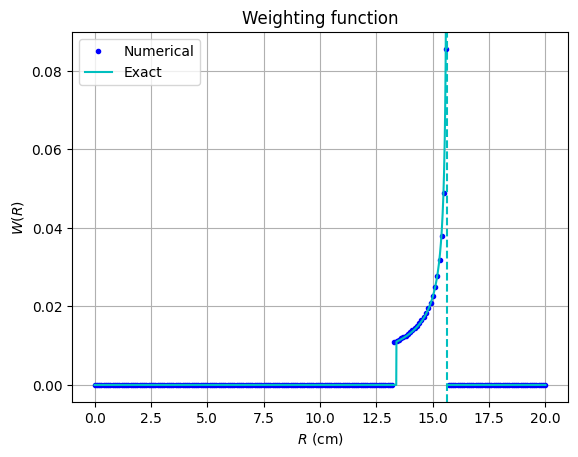

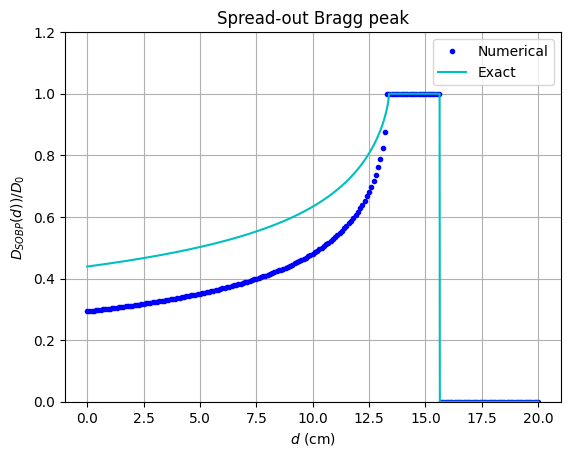


 HASIL EKSTRAKSI 24 BEAM BORTFELD UNTUK SIMULASI TOPAS
Layer Energi ke- 1 : 150.00 MeV (Jangkauan: 15.6 cm) -> 100000 partikel
Layer Energi ke- 2 : 149.27 MeV (Jangkauan: 15.5 cm) ->  56990 partikel
Layer Energi ke- 3 : 148.72 MeV (Jangkauan: 15.4 cm) ->  44371 partikel
Layer Energi ke- 4 : 148.17 MeV (Jangkauan: 15.3 cm) ->  37194 partikel
Layer Energi ke- 5 : 147.63 MeV (Jangkauan: 15.2 cm) ->  32483 partikel
Layer Energi ke- 6 : 147.08 MeV (Jangkauan: 15.1 cm) ->  29101 partikel
Layer Energi ke- 7 : 146.53 MeV (Jangkauan: 15.0 cm) ->  26530 partikel
Layer Energi ke- 8 : 145.97 MeV (Jangkauan: 14.9 cm) ->  24493 partikel
Layer Energi ke- 9 : 145.42 MeV (Jangkauan: 14.8 cm) ->  22832 partikel
Layer Energi ke-10 : 144.86 MeV (Jangkauan: 14.7 cm) ->  21446 partikel
Layer Energi ke-11 : 144.31 MeV (Jangkauan: 14.6 cm) ->  20266 partikel
Layer Energi ke-12 : 143.75 MeV (Jangkauan: 14.5 cm) ->  19248 partikel
Layer Energi ke-13 : 143.19 MeV (Jangkauan: 14.4 cm) ->  18359 partikel
Layer En

In [18]:
import numpy as np #150
from scipy import signal, integrate
import matplotlib.pyplot as plt

# =========================================================
# 1. PENGATURAN PARAMETER ENERGI DAN TARGET DINAMIS
# =========================================================
# Silakan ubah E_max ke 150.0, 100.0, atau berapapun yang Anda inginkan
E_max = 150       # Energi proyektil maksimal (dalam MeV) 
lebar_sobp = 2.25    # Lebar dataran SOBP yang diinginkan (dalam cm)

# Parameter Fisika Medium (PMMA/Air)
alpha = 0.0022      # Konstanta empiris
p = 1.77            # Eksponen empiris
D0 = 1.0            # Dosis target SOBP (Relatif)

# =========================================================
# KONVERSI OTOMATIS: Energi -> Kedalaman (Sumbu Z)
# =========================================================
# Rumus range-energy Bortfeld: R = alpha * E^p
db = alpha * (E_max ** p)     # Kedalaman berhentinya proton terdalam (Distal Edge)
da = db - lebar_sobp          # Kedalaman awal tumor (Proximal Edge)

print(f"Target Energi Max : {E_max} MeV")
print(f"Rentang SOBP      : {da:.2f} cm hingga {db:.2f} cm")

# Shorthand for oft-used expressions
a = alpha**(1.0/p)
q = 1.0 - 1.0/p

# Stopping power S = -dE/dd, mirrored about the y-axis and shifted by db (Bortfeld & Schlegel (1996), Eq. (A5))
def g(d):
    return np.piecewise(d,[d<0,d>0],[0,lambda d: 1.0/(p*a*d**q)])

def Bragg_peak(R,d):
    return g(R-d)

# Numerically computes the average of a function "func" on the interval [d0,d1]
def average(func,d0,d1):
    integral,_ = integrate.quad(func,d0,d1)/(d1-d0)
    return integral

# For a function defined for x>0, given an array x of grid values, returns an array of average
# function values on intervals [x[n]-dx/2, x[n]+dx/2], where x[n] is a grid value and dx the grid spacing
def impulse(func,x):
    h = np.zeros(len(x))
    dx = x[1] - x[0]
    h[0] = average(func, 0, 0.5*dx)
    for n in range(1,N):
        h[n] = average(func, x[n]-0.5*dx, x[n]+0.5*dx)
    return h

def W(R):
    return np.piecewise(R,[(da<=R) & (R<db)],[lambda R: D0*p*np.sin(np.pi/p)*a/(np.pi*(db-R)**(1.0/p)), 0])

# Performs the reverse of the transforms defined in Eq. (A3) of Bortfeld & Schlegel (1996)
def back_transform(w,da,db,x):
    N = len(x)
    dx = x[1] - x[0]
    Na = int(da/dx)
    Nb = int(db/dx)
    w = w[:Nb+1]
    w_reverse = w[::-1]
    return np.concatenate((np.zeros(Na), w_reverse[Na:Nb+1], np.zeros(N-Nb-1)))

# Part of the exact solution of the spread-out Bragg peak for p = 1.5 (Bortfeld & Schlegel (1996), Eq. (6))
def SOBP_buildup(d,da,db,D0):
    r = (da - d)/(db - da)
    r_hat = r**(1.0/3.0)
    return D0*(0.75+np.sqrt(3)/(4*np.pi)*np.log((1+r_hat)**2/(1-r_hat+r_hat**2))-3.0/(2.0*np.pi)*np.arctan((2*r_hat-1)/np.sqrt(3)))

# Full piecewise-defined analytical solution for the SOBP with p = 1.5 (Bortfeld & Schlegel (1996), Eq. (6))
def SOBP_analytic(d,da,db,D0):
    return np.piecewise(d,[(0<=d) & (d<da),(da<=d) & (d<=db)],[lambda d: SOBP_buildup(d,da,db,D0), D0, 0])

# Add grid and legend to plots
def add_grid_legend():
    plt.grid('on')
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, labels, loc = 'best')

# Definition of the depth grid
N = 201                         # Number of grid points
dmax = 20.0                     # Maximum depth up to which to generate model output
d = np.linspace(0,dmax,N)       # Depth grid
dd = d[1] - d[0]                # Depth grid spacing
Na = int(da/dd)                 # Grid point index corresponding to d = da
Nb = int(db/dd)                 # Grid point index corresponding to d = db

g_avs = impulse(g,d)            # Impulse response function (with averaging applied to remove singularity)

M = N                           # Length of inverse filter response w(R)
d_w = np.arange(M)*dd           # Depth grid for w(R)
Nd = M + N - 1                  # Number of output samples needed to obtain the inverse filter response of the required length

yd = D0*np.ones(Nd)             # Heaviside step function of length Nd

# Perform deconvolution of the step function with the averaged impulse response
w, remainder = signal.deconvolve(yd,g_avs)
w /= dd                        # Divide by grid spacing to obtain an approxiamtion of the continuous-valued weighting function

w2 = back_transform(w,da,db,d)

# Obtain the spread-out Bragg peak by deconvolution (cf. Bortfeld & Schlegel (1996), Eq. (B1))
SOBP = dd * signal.convolve(w2,g_avs[::-1])
SOBP = SOBP[N-1:]               # Remove boundary effects at the beginning of the convolution output

# Figure 1: Illustration of the Bragg peak
plt.figure(1)
Ncont = 2001                        # More finely spaced, 'continuous' grid for plotting exact solution
dcont = np.linspace(0,dmax,Ncont)
dx_cont = dcont[1] - dcont[0]

gx = Bragg_peak(db,dcont)           # Exact Bragg peak (Bortfeld & Schlegel, Eq. (3))
gx /= gx[0]                         # Normalize by value at d = 0
gx[int(db/dx_cont)] = np.nan                 # Set to not-a-number at the singularity at d = db

gn = impulse(lambda d: Bragg_peak(db,d),d)      # Discretized Bragg peak in which the singularity at d = db is removed by averaging
gn /= gn[0]                                     # Normalized by value at d = 0

plt.plot(d,gn,'b.',label='Averaged')
ymin,ymax = plt.gca().get_ylim()                # Record auto-scaled axis limits for the discrete (averaged) Bragg peak only
plt.plot(dcont,gx,'c',label='Exact')
plt.axvline(x=db,color='c',linestyle='--')
plt.title("Bragg peak")
plt.xlabel('$d$ (cm)')
plt.ylabel(r'$D_{BP}\left( d \right)/D_{BP}\left( 0 \right)$')
plt.gca().set_ylim(ymin,ymax)
add_grid_legend()

# Figure 2: Weighting function
plt.figure(2)
wx = W(dcont)           # Exact weighting function (Bortfeld & Schlegel (1996), Eq. (4))
wx[int(db/dx_cont)] = np.nan
plt.plot(d,w2,'b.',label='Numerical')
ymin,ymax = plt.gca().get_ylim()                # Record auto-scaled axis limits
plt.plot(dcont,wx,'c',label='Exact')
plt.axvline(x=db,color='c',linestyle='--')
plt.xlabel('$R$ (cm)')
plt.ylabel(r'$W\left(R\right)$')
plt.title('Weighting function')
plt.gca().set_ylim(ymin,ymax)
add_grid_legend()

# Figure 3: Spread-out Bragg peak
plt.figure(3)
plt.plot(d,SOBP,'b.',label='Numerical')
plt.plot(dcont,SOBP_analytic(dcont,da,db,D0),'c',label='Exact')
plt.xlabel('$d$ (cm)')
plt.ylabel('$D_{SOBP}(d))/D_0$')
plt.title('Spread-out Bragg peak')
plt.ylim([0,1.2*D0])
add_grid_legend()

plt.show()

# ---------------------------------------------------------

# ---------------------------------------------------------
# TAMBAHAN KODE UNTUK EKSTRAKSI DATA KE TOPAS
# ---------------------------------------------------------
# 1. Ekstrak Range (cm) dan Bobot mentah dari area target SOBP
# Tambahkan .copy() agar array asli tidak berubah saat kita modifikasi elemennya
beam_ranges = d[Na:Nb+1].copy()
beam_weights_raw = w2[Na:Nb+1]

# PERUBAHAN UTAMA: Paksa nilai range terakhir agar sama persis dengan db eksak
beam_ranges[-1] = db 

# 2. Konversi Range (cm) menjadi Energi (MeV)
# Karena elemen terakhir sekarang adalah db eksak, perhitungan baliknya akan menghasilkan E_max persis
beam_energies = (beam_ranges / alpha) ** (1.0 / p)

# 3. Normalisasi bobot menjadi skala jumlah partikel TOPAS (Maksimal 100.000 partikel)
max_weight = np.max(beam_weights_raw)

# 4. Tampilkan hasil dari Energi TERTINGGI (Paling dalam) ke TERENDAH
print(f"\n{'='*68}")
print(f" HASIL EKSTRAKSI {len(beam_ranges)} BEAM BORTFELD UNTUK SIMULASI TOPAS")
print(f"{'='*68}")

# Looping mundur agar urutan output dimulai dari energi penetrasi terdalam (15 cm) 
# yang dibutuhkan untuk file PRISTINE.txt
for i in range(len(beam_ranges) - 1, -1, -1):
    energi_mev = beam_energies[i]
    jangkauan_cm = beam_ranges[i]
    bobot = particle_weights[i]
    urutan = len(beam_ranges) - i
    
    print(f"Layer Energi ke-{urutan:2d} : {energi_mev:6.2f} MeV (Jangkauan: {jangkauan_cm:4.1f} cm) -> {bobot:6d} partikel")
print(f"{'='*68}\n")

Target Energi Max : 120 MeV
Rentang SOBP      : 8.28 cm hingga 10.53 cm


C:\Users\Asus\AppData\Local\Temp\ipykernel_31152\307609794.py:40: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  integral,_ = integrate.quad(func,d0,d1)/(d1-d0)


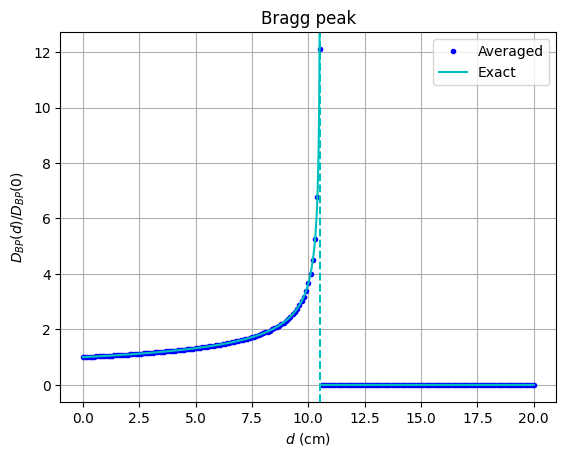

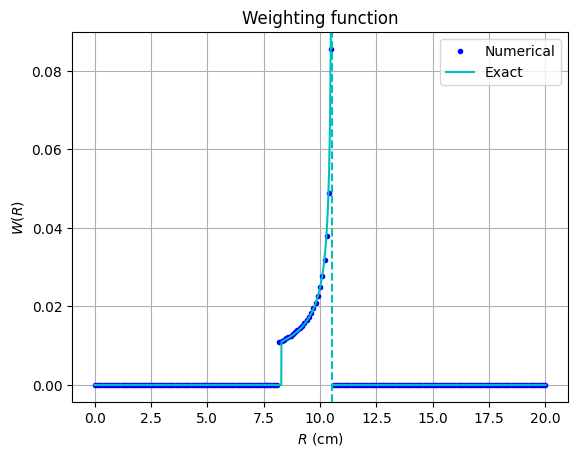

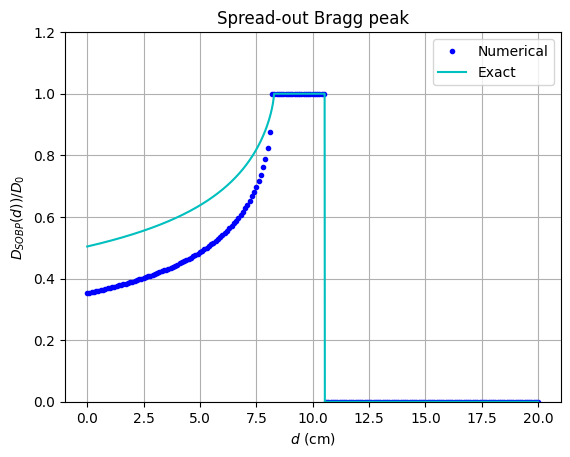


 HASIL EKSTRAKSI 24 BEAM BORTFELD UNTUK SIMULASI TOPAS
Layer Energi ke- 1 : 120.00 MeV (Jangkauan: 10.5 cm) -> 100000 partikel
Layer Energi ke- 2 : 119.14 MeV (Jangkauan: 10.4 cm) ->  56990 partikel
Layer Energi ke- 3 : 118.49 MeV (Jangkauan: 10.3 cm) ->  44371 partikel
Layer Energi ke- 4 : 117.84 MeV (Jangkauan: 10.2 cm) ->  37194 partikel
Layer Energi ke- 5 : 117.18 MeV (Jangkauan: 10.1 cm) ->  32483 partikel
Layer Energi ke- 6 : 116.53 MeV (Jangkauan: 10.0 cm) ->  29101 partikel
Layer Energi ke- 7 : 115.87 MeV (Jangkauan:  9.9 cm) ->  26530 partikel
Layer Energi ke- 8 : 115.20 MeV (Jangkauan:  9.8 cm) ->  24493 partikel
Layer Energi ke- 9 : 114.54 MeV (Jangkauan:  9.7 cm) ->  22832 partikel
Layer Energi ke-10 : 113.87 MeV (Jangkauan:  9.6 cm) ->  21446 partikel
Layer Energi ke-11 : 113.20 MeV (Jangkauan:  9.5 cm) ->  20266 partikel
Layer Energi ke-12 : 112.52 MeV (Jangkauan:  9.4 cm) ->  19248 partikel
Layer Energi ke-13 : 111.85 MeV (Jangkauan:  9.3 cm) ->  18359 partikel
Layer En

In [10]:
import numpy as np #120
from scipy import signal, integrate
import matplotlib.pyplot as plt

# =========================================================
# 1. PENGATURAN PARAMETER ENERGI DAN TARGET DINAMIS
# =========================================================
# Silakan ubah E_max ke 150.0, 100.0, atau berapapun yang Anda inginkan
E_max = 120       # Energi proyektil maksimal (dalam MeV) 
lebar_sobp = 2.25    # Lebar dataran SOBP yang diinginkan (dalam cm)

# Parameter Fisika Medium (PMMA/Air)
alpha = 0.0022      # Konstanta empiris
p = 1.77            # Eksponen empiris
D0 = 1.0            # Dosis target SOBP (Relatif)

# =========================================================
# KONVERSI OTOMATIS: Energi -> Kedalaman (Sumbu Z)
# =========================================================
# Rumus range-energy Bortfeld: R = alpha * E^p
db = alpha * (E_max ** p)     # Kedalaman berhentinya proton terdalam (Distal Edge)
da = db - lebar_sobp          # Kedalaman awal tumor (Proximal Edge)

print(f"Target Energi Max : {E_max} MeV")
print(f"Rentang SOBP      : {da:.2f} cm hingga {db:.2f} cm")

# Shorthand for oft-used expressions
a = alpha**(1.0/p)
q = 1.0 - 1.0/p

# Stopping power S = -dE/dd, mirrored about the y-axis and shifted by db (Bortfeld & Schlegel (1996), Eq. (A5))
def g(d):
    return np.piecewise(d,[d<0,d>0],[0,lambda d: 1.0/(p*a*d**q)])

def Bragg_peak(R,d):
    return g(R-d)

# Numerically computes the average of a function "func" on the interval [d0,d1]
def average(func,d0,d1):
    integral,_ = integrate.quad(func,d0,d1)/(d1-d0)
    return integral

# For a function defined for x>0, given an array x of grid values, returns an array of average
# function values on intervals [x[n]-dx/2, x[n]+dx/2], where x[n] is a grid value and dx the grid spacing
def impulse(func,x):
    h = np.zeros(len(x))
    dx = x[1] - x[0]
    h[0] = average(func, 0, 0.5*dx)
    for n in range(1,N):
        h[n] = average(func, x[n]-0.5*dx, x[n]+0.5*dx)
    return h

def W(R):
    return np.piecewise(R,[(da<=R) & (R<db)],[lambda R: D0*p*np.sin(np.pi/p)*a/(np.pi*(db-R)**(1.0/p)), 0])

# Performs the reverse of the transforms defined in Eq. (A3) of Bortfeld & Schlegel (1996)
def back_transform(w,da,db,x):
    N = len(x)
    dx = x[1] - x[0]
    Na = int(da/dx)
    Nb = int(db/dx)
    w = w[:Nb+1]
    w_reverse = w[::-1]
    return np.concatenate((np.zeros(Na), w_reverse[Na:Nb+1], np.zeros(N-Nb-1)))

# Part of the exact solution of the spread-out Bragg peak for p = 1.5 (Bortfeld & Schlegel (1996), Eq. (6))
def SOBP_buildup(d,da,db,D0):
    r = (da - d)/(db - da)
    r_hat = r**(1.0/3.0)
    return D0*(0.75+np.sqrt(3)/(4*np.pi)*np.log((1+r_hat)**2/(1-r_hat+r_hat**2))-3.0/(2.0*np.pi)*np.arctan((2*r_hat-1)/np.sqrt(3)))

# Full piecewise-defined analytical solution for the SOBP with p = 1.5 (Bortfeld & Schlegel (1996), Eq. (6))
def SOBP_analytic(d,da,db,D0):
    return np.piecewise(d,[(0<=d) & (d<da),(da<=d) & (d<=db)],[lambda d: SOBP_buildup(d,da,db,D0), D0, 0])

# Add grid and legend to plots
def add_grid_legend():
    plt.grid('on')
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, labels, loc = 'best')

# Definition of the depth grid
N = 201                         # Number of grid points
dmax = 20.0                     # Maximum depth up to which to generate model output
d = np.linspace(0,dmax,N)       # Depth grid
dd = d[1] - d[0]                # Depth grid spacing
Na = int(da/dd)                 # Grid point index corresponding to d = da
Nb = int(db/dd)                 # Grid point index corresponding to d = db

g_avs = impulse(g,d)            # Impulse response function (with averaging applied to remove singularity)

M = N                           # Length of inverse filter response w(R)
d_w = np.arange(M)*dd           # Depth grid for w(R)
Nd = M + N - 1                  # Number of output samples needed to obtain the inverse filter response of the required length

yd = D0*np.ones(Nd)             # Heaviside step function of length Nd

# Perform deconvolution of the step function with the averaged impulse response
w, remainder = signal.deconvolve(yd,g_avs)
w /= dd                        # Divide by grid spacing to obtain an approxiamtion of the continuous-valued weighting function

w2 = back_transform(w,da,db,d)

# Obtain the spread-out Bragg peak by deconvolution (cf. Bortfeld & Schlegel (1996), Eq. (B1))
SOBP = dd * signal.convolve(w2,g_avs[::-1])
SOBP = SOBP[N-1:]               # Remove boundary effects at the beginning of the convolution output

# Figure 1: Illustration of the Bragg peak
plt.figure(1)
Ncont = 2001                        # More finely spaced, 'continuous' grid for plotting exact solution
dcont = np.linspace(0,dmax,Ncont)
dx_cont = dcont[1] - dcont[0]

gx = Bragg_peak(db,dcont)           # Exact Bragg peak (Bortfeld & Schlegel, Eq. (3))
gx /= gx[0]                         # Normalize by value at d = 0
gx[int(db/dx_cont)] = np.nan                 # Set to not-a-number at the singularity at d = db

gn = impulse(lambda d: Bragg_peak(db,d),d)      # Discretized Bragg peak in which the singularity at d = db is removed by averaging
gn /= gn[0]                                     # Normalized by value at d = 0

plt.plot(d,gn,'b.',label='Averaged')
ymin,ymax = plt.gca().get_ylim()                # Record auto-scaled axis limits for the discrete (averaged) Bragg peak only
plt.plot(dcont,gx,'c',label='Exact')
plt.axvline(x=db,color='c',linestyle='--')
plt.title("Bragg peak")
plt.xlabel('$d$ (cm)')
plt.ylabel(r'$D_{BP}\left( d \right)/D_{BP}\left( 0 \right)$')
plt.gca().set_ylim(ymin,ymax)
add_grid_legend()

# Figure 2: Weighting function
plt.figure(2)
wx = W(dcont)           # Exact weighting function (Bortfeld & Schlegel (1996), Eq. (4))
wx[int(db/dx_cont)] = np.nan
plt.plot(d,w2,'b.',label='Numerical')
ymin,ymax = plt.gca().get_ylim()                # Record auto-scaled axis limits
plt.plot(dcont,wx,'c',label='Exact')
plt.axvline(x=db,color='c',linestyle='--')
plt.xlabel('$R$ (cm)')
plt.ylabel(r'$W\left(R\right)$')
plt.title('Weighting function')
plt.gca().set_ylim(ymin,ymax)
add_grid_legend()

# Figure 3: Spread-out Bragg peak
plt.figure(3)
plt.plot(d,SOBP,'b.',label='Numerical')
plt.plot(dcont,SOBP_analytic(dcont,da,db,D0),'c',label='Exact')
plt.xlabel('$d$ (cm)')
plt.ylabel('$D_{SOBP}(d))/D_0$')
plt.title('Spread-out Bragg peak')
plt.ylim([0,1.2*D0])
add_grid_legend()

plt.show()

# ---------------------------------------------------------

# ---------------------------------------------------------
# TAMBAHAN KODE UNTUK EKSTRAKSI DATA KE TOPAS
# ---------------------------------------------------------
# 1. Ekstrak Range (cm) dan Bobot mentah dari area target SOBP
# Tambahkan .copy() agar array asli tidak berubah saat kita modifikasi elemennya
beam_ranges = d[Na:Nb+1].copy()
beam_weights_raw = w2[Na:Nb+1]

# PERUBAHAN UTAMA: Paksa nilai range terakhir agar sama persis dengan db eksak
beam_ranges[-1] = db 

# 2. Konversi Range (cm) menjadi Energi (MeV)
# Karena elemen terakhir sekarang adalah db eksak, perhitungan baliknya akan menghasilkan E_max persis
beam_energies = (beam_ranges / alpha) ** (1.0 / p)

# 3. Normalisasi bobot menjadi skala jumlah partikel TOPAS (Maksimal 100.000 partikel)
max_weight = np.max(beam_weights_raw)

# 4. Tampilkan hasil dari Energi TERTINGGI (Paling dalam) ke TERENDAH
print(f"\n{'='*68}")
print(f" HASIL EKSTRAKSI {len(beam_ranges)} BEAM BORTFELD UNTUK SIMULASI TOPAS")
print(f"{'='*68}")

# Looping mundur agar urutan output dimulai dari energi penetrasi terdalam (15 cm) 
# yang dibutuhkan untuk file PRISTINE.txt
for i in range(len(beam_ranges) - 1, -1, -1):
    energi_mev = beam_energies[i]
    jangkauan_cm = beam_ranges[i]
    bobot = particle_weights[i]
    urutan = len(beam_ranges) - i
    
    print(f"Layer Energi ke-{urutan:2d} : {energi_mev:6.2f} MeV (Jangkauan: {jangkauan_cm:4.1f} cm) -> {bobot:6d} partikel")
print(f"{'='*68}\n")

Target Energi Max : 200 MeV
Rentang SOBP      : 23.77 cm hingga 26.02 cm


C:\Users\Asus\AppData\Local\Temp\ipykernel_31152\4193810723.py:40: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  integral,_ = integrate.quad(func,d0,d1)/(d1-d0)


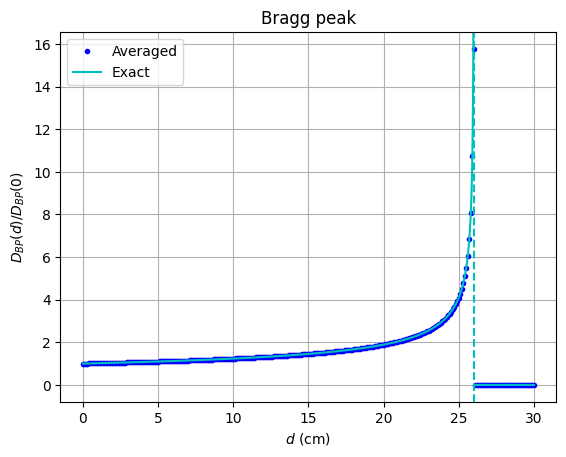

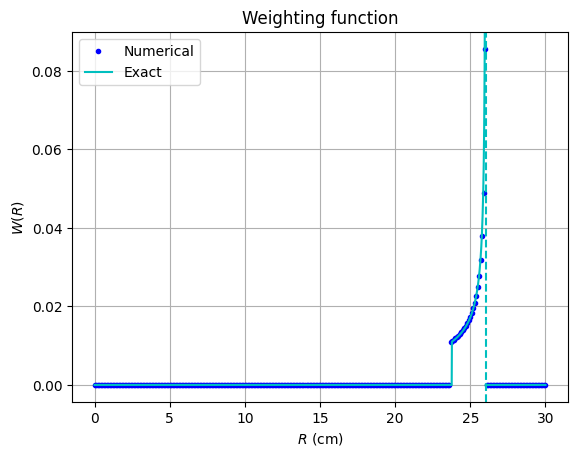

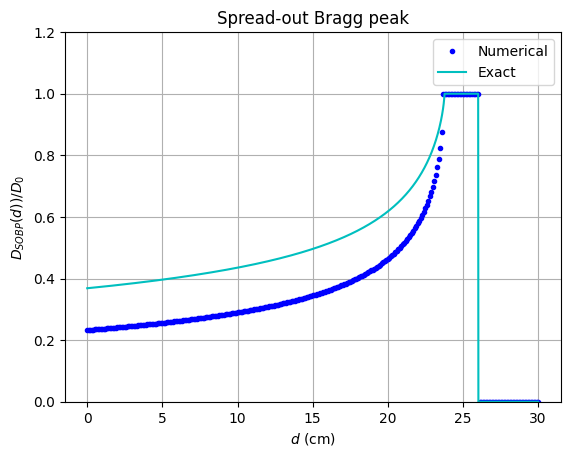


 HASIL EKSTRAKSI 24 BEAM BORTFELD UNTUK SIMULASI TOPAS
Layer Energi ke- 1 : 200.00 MeV (Jangkauan: 26.0 cm) -> 100000 partikel
Layer Energi ke- 2 : 199.49 MeV (Jangkauan: 25.9 cm) ->  56990 partikel
Layer Energi ke- 3 : 199.06 MeV (Jangkauan: 25.8 cm) ->  44371 partikel
Layer Energi ke- 4 : 198.62 MeV (Jangkauan: 25.7 cm) ->  37194 partikel
Layer Energi ke- 5 : 198.19 MeV (Jangkauan: 25.6 cm) ->  32483 partikel
Layer Energi ke- 6 : 197.75 MeV (Jangkauan: 25.5 cm) ->  29101 partikel
Layer Energi ke- 7 : 197.31 MeV (Jangkauan: 25.4 cm) ->  26530 partikel
Layer Energi ke- 8 : 196.87 MeV (Jangkauan: 25.3 cm) ->  24493 partikel
Layer Energi ke- 9 : 196.43 MeV (Jangkauan: 25.2 cm) ->  22832 partikel
Layer Energi ke-10 : 195.99 MeV (Jangkauan: 25.1 cm) ->  21446 partikel
Layer Energi ke-11 : 195.55 MeV (Jangkauan: 25.0 cm) ->  20266 partikel
Layer Energi ke-12 : 195.11 MeV (Jangkauan: 24.9 cm) ->  19248 partikel
Layer Energi ke-13 : 194.66 MeV (Jangkauan: 24.8 cm) ->  18359 partikel
Layer En

In [12]:
import numpy as np #200
from scipy import signal, integrate
import matplotlib.pyplot as plt

# =========================================================
# 1. PENGATURAN PARAMETER ENERGI DAN TARGET DINAMIS
# =========================================================
# Silakan ubah E_max ke 150.0, 100.0, atau berapapun yang Anda inginkan
E_max = 200       # Energi proyektil maksimal (dalam MeV) 
lebar_sobp = 2.25    # Lebar dataran SOBP yang diinginkan (dalam cm)

# Parameter Fisika Medium (PMMA/Air)
alpha = 0.0022      # Konstanta empiris
p = 1.77            # Eksponen empiris
D0 = 1.0            # Dosis target SOBP (Relatif)

# =========================================================
# KONVERSI OTOMATIS: Energi -> Kedalaman (Sumbu Z)
# =========================================================
# Rumus range-energy Bortfeld: R = alpha * E^p
db = alpha * (E_max ** p)     # Kedalaman berhentinya proton terdalam (Distal Edge)
da = db - lebar_sobp          # Kedalaman awal tumor (Proximal Edge)

print(f"Target Energi Max : {E_max} MeV")
print(f"Rentang SOBP      : {da:.2f} cm hingga {db:.2f} cm")

# Shorthand for oft-used expressions
a = alpha**(1.0/p)
q = 1.0 - 1.0/p

# Stopping power S = -dE/dd, mirrored about the y-axis and shifted by db (Bortfeld & Schlegel (1996), Eq. (A5))
def g(d):
    return np.piecewise(d,[d<0,d>0],[0,lambda d: 1.0/(p*a*d**q)])

def Bragg_peak(R,d):
    return g(R-d)

# Numerically computes the average of a function "func" on the interval [d0,d1]
def average(func,d0,d1):
    integral,_ = integrate.quad(func,d0,d1)/(d1-d0)
    return integral

# For a function defined for x>0, given an array x of grid values, returns an array of average
# function values on intervals [x[n]-dx/2, x[n]+dx/2], where x[n] is a grid value and dx the grid spacing
def impulse(func,x):
    h = np.zeros(len(x))
    dx = x[1] - x[0]
    h[0] = average(func, 0, 0.5*dx)
    for n in range(1,N):
        h[n] = average(func, x[n]-0.5*dx, x[n]+0.5*dx)
    return h

def W(R):
    return np.piecewise(R,[(da<=R) & (R<db)],[lambda R: D0*p*np.sin(np.pi/p)*a/(np.pi*(db-R)**(1.0/p)), 0])

# Performs the reverse of the transforms defined in Eq. (A3) of Bortfeld & Schlegel (1996)
def back_transform(w,da,db,x):
    N = len(x)
    dx = x[1] - x[0]
    Na = int(da/dx)
    Nb = int(db/dx)
    w = w[:Nb+1]
    w_reverse = w[::-1]
    return np.concatenate((np.zeros(Na), w_reverse[Na:Nb+1], np.zeros(N-Nb-1)))

# Part of the exact solution of the spread-out Bragg peak for p = 1.5 (Bortfeld & Schlegel (1996), Eq. (6))
def SOBP_buildup(d,da,db,D0):
    r = (da - d)/(db - da)
    r_hat = r**(1.0/3.0)
    return D0*(0.75+np.sqrt(3)/(4*np.pi)*np.log((1+r_hat)**2/(1-r_hat+r_hat**2))-3.0/(2.0*np.pi)*np.arctan((2*r_hat-1)/np.sqrt(3)))

# Full piecewise-defined analytical solution for the SOBP with p = 1.5 (Bortfeld & Schlegel (1996), Eq. (6))
def SOBP_analytic(d,da,db,D0):
    return np.piecewise(d,[(0<=d) & (d<da),(da<=d) & (d<=db)],[lambda d: SOBP_buildup(d,da,db,D0), D0, 0])

# Add grid and legend to plots
def add_grid_legend():
    plt.grid('on')
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, labels, loc = 'best')

# Definition of the depth grid
N = 301                         # Number of grid points
dmax = 30.0                     # Maximum depth up to which to generate model output
d = np.linspace(0,dmax,N)       # Depth grid
dd = d[1] - d[0]                # Depth grid spacing
Na = int(da/dd)                 # Grid point index corresponding to d = da
Nb = int(db/dd)                 # Grid point index corresponding to d = db

g_avs = impulse(g,d)            # Impulse response function (with averaging applied to remove singularity)

M = N                           # Length of inverse filter response w(R)
d_w = np.arange(M)*dd           # Depth grid for w(R)
Nd = M + N - 1                  # Number of output samples needed to obtain the inverse filter response of the required length

yd = D0*np.ones(Nd)             # Heaviside step function of length Nd

# Perform deconvolution of the step function with the averaged impulse response
w, remainder = signal.deconvolve(yd,g_avs)
w /= dd                        # Divide by grid spacing to obtain an approxiamtion of the continuous-valued weighting function

w2 = back_transform(w,da,db,d)

# Obtain the spread-out Bragg peak by deconvolution (cf. Bortfeld & Schlegel (1996), Eq. (B1))
SOBP = dd * signal.convolve(w2,g_avs[::-1])
SOBP = SOBP[N-1:]               # Remove boundary effects at the beginning of the convolution output

# Figure 1: Illustration of the Bragg peak
plt.figure(1)
Ncont = 2001                        # More finely spaced, 'continuous' grid for plotting exact solution
dcont = np.linspace(0,dmax,Ncont)
dx_cont = dcont[1] - dcont[0]

gx = Bragg_peak(db,dcont)           # Exact Bragg peak (Bortfeld & Schlegel, Eq. (3))
gx /= gx[0]                         # Normalize by value at d = 0
gx[int(db/dx_cont)] = np.nan                 # Set to not-a-number at the singularity at d = db

gn = impulse(lambda d: Bragg_peak(db,d),d)      # Discretized Bragg peak in which the singularity at d = db is removed by averaging
gn /= gn[0]                                     # Normalized by value at d = 0

plt.plot(d,gn,'b.',label='Averaged')
ymin,ymax = plt.gca().get_ylim()                # Record auto-scaled axis limits for the discrete (averaged) Bragg peak only
plt.plot(dcont,gx,'c',label='Exact')
plt.axvline(x=db,color='c',linestyle='--')
plt.title("Bragg peak")
plt.xlabel('$d$ (cm)')
plt.ylabel(r'$D_{BP}\left( d \right)/D_{BP}\left( 0 \right)$')
plt.gca().set_ylim(ymin,ymax)
add_grid_legend()

# Figure 2: Weighting function
plt.figure(2)
wx = W(dcont)           # Exact weighting function (Bortfeld & Schlegel (1996), Eq. (4))
wx[int(db/dx_cont)] = np.nan
plt.plot(d,w2,'b.',label='Numerical')
ymin,ymax = plt.gca().get_ylim()                # Record auto-scaled axis limits
plt.plot(dcont,wx,'c',label='Exact')
plt.axvline(x=db,color='c',linestyle='--')
plt.xlabel('$R$ (cm)')
plt.ylabel(r'$W\left(R\right)$')
plt.title('Weighting function')
plt.gca().set_ylim(ymin,ymax)
add_grid_legend()

# Figure 3: Spread-out Bragg peak
plt.figure(3)
plt.plot(d,SOBP,'b.',label='Numerical')
plt.plot(dcont,SOBP_analytic(dcont,da,db,D0),'c',label='Exact')
plt.xlabel('$d$ (cm)')
plt.ylabel('$D_{SOBP}(d))/D_0$')
plt.title('Spread-out Bragg peak')
plt.ylim([0,1.2*D0])
add_grid_legend()

plt.show()

# ---------------------------------------------------------
# ---------------------------------------------------------
# TAMBAHAN KODE UNTUK EKSTRAKSI DATA KE TOPAS
# ---------------------------------------------------------
# 1. Ekstrak Range (cm) dan Bobot mentah dari area target SOBP
# Tambahkan .copy() agar array asli tidak berubah saat kita modifikasi elemennya
beam_ranges = d[Na:Nb+1].copy()
beam_weights_raw = w2[Na:Nb+1]

# PERUBAHAN UTAMA: Paksa nilai range terakhir agar sama persis dengan db eksak
beam_ranges[-1] = db 

# 2. Konversi Range (cm) menjadi Energi (MeV)
# Karena elemen terakhir sekarang adalah db eksak, perhitungan baliknya akan menghasilkan E_max persis
beam_energies = (beam_ranges / alpha) ** (1.0 / p)

# 3. Normalisasi bobot menjadi skala jumlah partikel TOPAS (Maksimal 100.000 partikel)
max_weight = np.max(beam_weights_raw)

# 4. Tampilkan hasil dari Energi TERTINGGI (Paling dalam) ke TERENDAH
print(f"\n{'='*68}")
print(f" HASIL EKSTRAKSI {len(beam_ranges)} BEAM BORTFELD UNTUK SIMULASI TOPAS")
print(f"{'='*68}")

# Looping mundur agar urutan output dimulai dari energi penetrasi terdalam (15 cm) 
# yang dibutuhkan untuk file PRISTINE.txt
for i in range(len(beam_ranges) - 1, -1, -1):
    energi_mev = beam_energies[i]
    jangkauan_cm = beam_ranges[i]
    bobot = particle_weights[i]
    urutan = len(beam_ranges) - i
    
    print(f"Layer Energi ke-{urutan:2d} : {energi_mev:6.2f} MeV (Jangkauan: {jangkauan_cm:4.1f} cm) -> {bobot:6d} partikel")
print(f"{'='*68}\n")

In [11]:
# ---------------------------------------------------------
# TAMBAHAN KODE UNTUK EKSTRAKSI DATA KE TOPAS
# ---------------------------------------------------------
# 1. Ekstrak Range (cm) dan Bobot mentah dari area target SOBP
# Indeks Na hingga Nb mewakili kedalaman dari 13.0 cm s/d 15.0 cm
beam_ranges = d[Na:Nb+1]
beam_weights_raw = w2[Na:Nb+1]

# 2. Konversi Range (cm) menjadi Energi (MeV)
# Menggunakan balikan rumus empiris Bortfeld: R = alpha * E^p -> E = (R / alpha)**(1/p)
beam_energies = (beam_ranges / alpha) ** (1.0 / p)

# 3. Normalisasi bobot menjadi skala jumlah partikel TOPAS (Maksimal 100.000 partikel)
max_weight = np.max(beam_weights_raw)
particle_weights = np.round((beam_weights_raw / max_weight) * 100000).astype(int)

# 4. Tampilkan hasil dari Energi TERTINGGI (Paling dalam) ke TERENDAH
print(f"\n{'='*68}")
print(f" HASIL EKSTRAKSI {len(beam_ranges)} BEAM BORTFELD UNTUK SIMULASI TOPAS")
print(f"{'='*68}")

# Looping mundur agar urutan output dimulai dari energi penetrasi terdalam (15 cm) 
# yang dibutuhkan untuk file PRISTINE.txt
for i in range(len(beam_ranges) - 1, -1, -1):
    energi_mev = beam_energies[i]
    jangkauan_cm = beam_ranges[i]
    bobot = particle_weights[i]
    urutan = len(beam_ranges) - i
    
    print(f"Layer Energi ke-{urutan:2d} : {energi_mev:6.2f} MeV (Jangkauan: {jangkauan_cm:4.1f} cm) -> {bobot:6d} partikel")
print(f"{'='*68}\n")


 HASIL EKSTRAKSI 24 BEAM BORTFELD UNTUK SIMULASI TOPAS
Layer Energi ke- 1 : 119.78 MeV (Jangkauan: 10.5 cm) -> 100000 partikel
Layer Energi ke- 2 : 119.14 MeV (Jangkauan: 10.4 cm) ->  56990 partikel
Layer Energi ke- 3 : 118.49 MeV (Jangkauan: 10.3 cm) ->  44371 partikel
Layer Energi ke- 4 : 117.84 MeV (Jangkauan: 10.2 cm) ->  37194 partikel
Layer Energi ke- 5 : 117.18 MeV (Jangkauan: 10.1 cm) ->  32483 partikel
Layer Energi ke- 6 : 116.53 MeV (Jangkauan: 10.0 cm) ->  29101 partikel
Layer Energi ke- 7 : 115.87 MeV (Jangkauan:  9.9 cm) ->  26530 partikel
Layer Energi ke- 8 : 115.20 MeV (Jangkauan:  9.8 cm) ->  24493 partikel
Layer Energi ke- 9 : 114.54 MeV (Jangkauan:  9.7 cm) ->  22832 partikel
Layer Energi ke-10 : 113.87 MeV (Jangkauan:  9.6 cm) ->  21446 partikel
Layer Energi ke-11 : 113.20 MeV (Jangkauan:  9.5 cm) ->  20266 partikel
Layer Energi ke-12 : 112.52 MeV (Jangkauan:  9.4 cm) ->  19248 partikel
Layer Energi ke-13 : 111.85 MeV (Jangkauan:  9.3 cm) ->  18359 partikel
Layer En

In [2]:
import numpy as np
from scipy import signal, integrate

# =====================================
# INPUT
# =====================================

E_max = 120
sobp_width = 2.25

alpha = 0.0022
p = 1.77

N = 201
dmax = 20

# =====================================
# KONVERSI RANGE
# =====================================

db = alpha*(E_max**p)
da = db-sobp_width

print(f"Target : {da:.2f}–{db:.2f} cm")

a = alpha**(1/p)
q = 1-(1/p)

# =====================================
# MODEL BRAGG
# =====================================

def g(d):
    return np.where(
        d>0,
        1/(p*a*d**q),
        0
    )

def average(func,a,b):
    integral,_=integrate.quad(
        func,
        a,
        b
    )
    
    return integral/(b-a)

def impulse(func,x):

    dx=x[1]-x[0]

    h=np.zeros(len(x))

    for i in range(len(x)):

        x0=max(
            0,
            x[i]-dx/2
        )

        x1=x[i]+dx/2

        h[i]=average(
            func,
            x0,
            x1
        )

    return h

# =====================================
# GRID
# =====================================

d=np.linspace(
    0,
    dmax,
    N
)

dd=d[1]-d[0]

g_av=impulse(
    g,
    d
)

# =====================================
# DECONVOLUTION
# =====================================

yd=np.ones(
    2*N-1
)

w,_=signal.deconvolve(
    yd,
    g_av
)

w=w/dd

# =====================================
# EKSTRAK AREA SOBP
# =====================================

mask=(
    (d>=da)&
    (d<=db)
)

ranges=d[mask]

weights=np.abs(
    w[:len(ranges)]
)

energies=(
    ranges/
    alpha
)**(1/p)

# =====================================
# SIMPAN ENERGI
# =====================================

with open(
    "energy_layers.txt",
    "w"
) as f:

    for E in energies[::-1]:

        f.write(
            f"{E:.2f}\n"
        )

print(
    f"{len(energies)} layer dibuat"
)

Target : 8.28–10.53 cm
23 layer dibuat


In [3]:
import numpy as np
from scipy import signal, integrate
import pandas as pd

# ==========================================
# INPUT
# ==========================================

E_max = 120
lebar_sobp = 2.25

alpha = 0.0022
p = 1.77
D0 = 1

N = 201
dmax = 20

# ==========================================
# KONVERSI RANGE
# ==========================================

db = alpha*(E_max**p)
da = db-lebar_sobp

print("\n=== TARGET SOBP ===")
print(f"Emax      : {E_max:.2f} MeV")
print(f"Proksimal : {da:.2f} cm")
print(f"Distal    : {db:.2f} cm")

a = alpha**(1/p)
q = 1-(1/p)

# ==========================================
# MODEL BRAGG
# ==========================================

def g(d):

    return np.piecewise(
        d,
        [d<0,d>0],
        [
            0,
            lambda d:
            1/(p*a*d**q)
        ]
    )

def average(func,d0,d1):

    integral,_=integrate.quad(
        func,
        d0,
        d1
    )

    return integral/(d1-d0)

def impulse(func,x):

    h=np.zeros(len(x))

    dx=x[1]-x[0]

    for i in range(len(x)):

        x0=max(
            0,
            x[i]-dx/2
        )

        x1=x[i]+dx/2

        h[i]=average(
            func,
            x0,
            x1
        )

    return h

# ==========================================
# GRID
# ==========================================

d=np.linspace(
    0,
    dmax,
    N
)

dd=d[1]-d[0]

Na=int(da/dd)
Nb=int(db/dd)

# ==========================================
# DECONVOLUTION
# ==========================================

g_av=impulse(
    g,
    d
)

yd=np.ones(
    2*N-1
)

w,_=signal.deconvolve(
    yd,
    g_av
)

w/=dd

# ==========================================
# AMBIL AREA SOBP
# ==========================================

beam_ranges=d[
    Na:
    Nb+1
]

beam_weights=np.abs(
    w[
        :
        len(beam_ranges)
    ]
)

beam_energies=(
    beam_ranges/
    alpha
)**(
    1/p
)

# normalisasi awal
beam_weights=(
beam_weights/
beam_weights.max()
)

# ==========================================
# CETAK HASIL
# ==========================================

print("\n=== LAYER ENERGI ===\n")

for i in range(
    len(
        beam_energies
    )-1,
    -1,
    -1
):

    print(
        f"{len(beam_energies)-i:2d}"
        f" | "
        f"{beam_energies[i]:7.2f} MeV"
        f" | "
        f"Range {beam_ranges[i]:5.2f} cm"
        f" | "
        f"W={beam_weights[i]:.4f}"
    )

# ==========================================
# SIMPAN FILE
# ==========================================

hasil=pd.DataFrame({

"Layer":

np.arange(
1,
len(
beam_energies
)+1
),

"Energy_MeV":

beam_energies[::-1],

"Range_cm":

beam_ranges[::-1],

"Weight":

beam_weights[::-1]

})

hasil.to_csv(

"energy_layers.csv",

index=False

)

print(
"\nSelesai → energy_layers.csv"
)


=== TARGET SOBP ===
Emax      : 120.00 MeV
Proksimal : 8.28 cm
Distal    : 10.53 cm

=== LAYER ENERGI ===

 1 |  119.78 MeV | Range 10.50 cm | W=0.1281
 2 |  119.14 MeV | Range 10.40 cm | W=0.1313
 3 |  118.49 MeV | Range 10.30 cm | W=0.1348
 4 |  117.84 MeV | Range 10.20 cm | W=0.1385
 5 |  117.18 MeV | Range 10.10 cm | W=0.1425
 6 |  116.53 MeV | Range 10.00 cm | W=0.1468
 7 |  115.87 MeV | Range  9.90 cm | W=0.1516
 8 |  115.20 MeV | Range  9.80 cm | W=0.1568
 9 |  114.54 MeV | Range  9.70 cm | W=0.1624
10 |  113.87 MeV | Range  9.60 cm | W=0.1687
11 |  113.20 MeV | Range  9.50 cm | W=0.1757
12 |  112.52 MeV | Range  9.40 cm | W=0.1836
13 |  111.85 MeV | Range  9.30 cm | W=0.1925
14 |  111.17 MeV | Range  9.20 cm | W=0.2027
15 |  110.48 MeV | Range  9.10 cm | W=0.2145
16 |  109.79 MeV | Range  9.00 cm | W=0.2283
17 |  109.10 MeV | Range  8.90 cm | W=0.2449
18 |  108.41 MeV | Range  8.80 cm | W=0.2653
19 |  107.71 MeV | Range  8.70 cm | W=0.2910
20 |  107.01 MeV | Range  8.60 cm | W